# Smart Urban EV Analytics Platform - Mini Prototype
## AI-Powered EV Charging Station Optimization for Chennai

This project demonstrates how machine learning can optimize EV charging station placement in Chennai using K-Means clustering.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins

In [4]:
from math import radians, cos, sin, asin, sqrt
import random

np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Distance Calculation Function

In [5]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great circle distance between two points using Haversine formula
    Returns distance in kilometers
    """
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    r = 6371  # Earth radius in km
    return c * r

## Generate Chennai Locations

In [6]:
def generate_chennai_locations(n_locations=75):
    chennai_bounds = {
        'north': 13.2847,
        'south': 12.8348, 
        'east': 80.3303,
        'west': 80.0955
    }
    
    landmarks = {
        'Central_Chennai': (13.0827, 80.2707),
        'OMR_IT_Corridor': (12.8406, 80.2280),
        'Airport': (12.9941, 80.1709),
        'North_Chennai': (13.1500, 80.2500),
        'South_Chennai': (12.9500, 80.2200),
    }
    
    locations = []
    location_types = ['Commercial', 'Residential', 'Mixed', 'Industrial', 'Transport Hub']
    
    return locations, landmarks, location_types, chennai_bounds

In [7]:
locations, landmarks, location_types, chennai_bounds = generate_chennai_locations()

In [8]:
# Generate candidate locations
locations = []
for i in range(75):
    if i < len(landmarks) * 8:  # 80% near landmarks
        landmark = random.choice(list(landmarks.keys()))
        base_lat, base_lon = landmarks[landmark]
        lat = base_lat + np.random.normal(0, 0.02)
        lon = base_lon + np.random.normal(0, 0.02)
    else:  # 20% random
        lat = np.random.uniform(chennai_bounds['south'], chennai_bounds['north'])
        lon = np.random.uniform(chennai_bounds['west'], chennai_bounds['east'])
    
    lat = np.clip(lat, chennai_bounds['south'], chennai_bounds['north'])
    lon = np.clip(lon, chennai_bounds['west'], chennai_bounds['east'])
    
    location_type = np.random.choice(location_types)
    
    location = {
        'location_id': f'LOC_{i:03d}',
        'latitude': round(lat, 6),
        'longitude': round(lon, 6),
        'location_type': location_type,
        'area_name': f'Area_{i:03d}'
    }
    locations.append(location)

In [9]:
candidate_locations = pd.DataFrame(locations)
print(f"Generated {len(candidate_locations)} candidate locations")
candidate_locations.head()

Generated 75 candidate locations


,location_id,latitude,longitude,location_type,area_name
0,LOC_000,13.092634,80.267935,Mixed,Area_000
1,LOC_001,13.092177,80.298069,Residential,Area_001
2,LOC_002,12.999681,80.191110,Mixed,Area_002
3,LOC_003,12.834800,80.238851,Industrial,Area_003
4,LOC_004,12.834800,80.209518,Transport Hub,Area_004


## Feature Engineering

In [10]:
def calculate_features(df):
    df = df.copy()
    chennai_center = (13.0827, 80.2707)
    
    landmarks = {
        'airport': (12.9941, 80.1709),
        'omr_start': (12.9716, 80.2417),
        'central_station': (13.0827, 80.2707)
    }
    
    return df, chennai_center, landmarks

In [11]:
featured_data, chennai_center, landmarks = calculate_features(candidate_locations)

# Distance to Chennai center
featured_data['distance_to_center'] = featured_data.apply(
    lambda row: haversine_distance(
        row['latitude'], row['longitude'], chennai_center[0], chennai_center[1]
    ), axis=1
)

In [12]:
# Distances to key landmarks
for landmark, coords in landmarks.items():
    featured_data[f'distance_to_{landmark}'] = featured_data.apply(
        lambda row: haversine_distance(
            row['latitude'], row['longitude'], coords[0], coords[1]
        ), axis=1
    )

In [13]:
# Demand score calculation
def calculate_demand_score(row):
    base_score = 0.3
    
    type_multipliers = {
        'Commercial': 1.0,
        'Transport Hub': 0.9,
        'Mixed': 0.8,
        'Industrial': 0.6,
        'Residential': 0.5
    }
    
    distance_factor = max(0.1, 1.0 - (row['distance_to_center'] / 25.0))
    airport_bonus = 0.2 if row['distance_to_airport'] < 5.0 else 0
    omr_bonus = 0.3 if row['distance_to_omr_start'] < 3.0 else 0
    
    total_score = (
        base_score * type_multipliers.get(row['location_type'], 0.5) * 
        distance_factor + airport_bonus + omr_bonus
    )
    
    return min(1.0, total_score)

featured_data['demand_score'] = featured_data.apply(calculate_demand_score, axis=1)

In [14]:
# Land cost estimation
def estimate_land_cost(row):
    base_cost = 50
    distance_multiplier = max(0.5, 2.0 - (row['distance_to_center'] / 15.0))
    
    type_multipliers = {
        'Commercial': 2.0,
        'Transport Hub': 1.8,
        'Mixed': 1.4,
        'Industrial': 1.0,
        'Residential': 1.2
    }
    
    cost = base_cost * distance_multiplier * type_multipliers.get(row['location_type'], 1.0)
    variation = np.random.uniform(0.8, 1.2)
    
    return round(cost * variation, 1)

featured_data['land_cost_lakhs'] = featured_data.apply(estimate_land_cost, axis=1)

In [15]:
# Population density estimation
def estimate_population_density(row):
    if row['distance_to_center'] < 5:
        base_density = np.random.uniform(8000, 15000)
    elif row['distance_to_center'] < 15:
        base_density = np.random.uniform(4000, 8000)
    else:
        base_density = np.random.uniform(1000, 4000)
    
    type_multipliers = {
        'Commercial': 1.5,
        'Mixed': 1.3,
        'Residential': 1.0,
        'Transport Hub': 1.2,
        'Industrial': 0.7
    }
    
    density = base_density * type_multipliers.get(row['location_type'], 1.0)
    return round(density, 0)

featured_data['population_density'] = featured_data.apply(estimate_population_density, axis=1)

In [16]:
print("Feature engineering completed!")
print(f"Total features: {len(featured_data.columns)}")
featured_data[['location_id', 'demand_score', 'land_cost_lakhs', 'distance_to_center', 'population_density']].head()

Feature engineering completed!
Total features: 12


,location_id,demand_score,land_cost_lakhs,distance_to_center,population_density
0,LOC_000,0.229013,150.5,1.144485,19280.0
1,LOC_001,0.131124,107.5,3.145988,11614.0
2,LOC_002,0.318739,83.5,12.631359,6879.0
3,LOC_003,0.018000,24.9,27.780436,2370.0
4,LOC_004,0.027000,39.5,28.351305,2175.0


## Exploratory Data Analysis

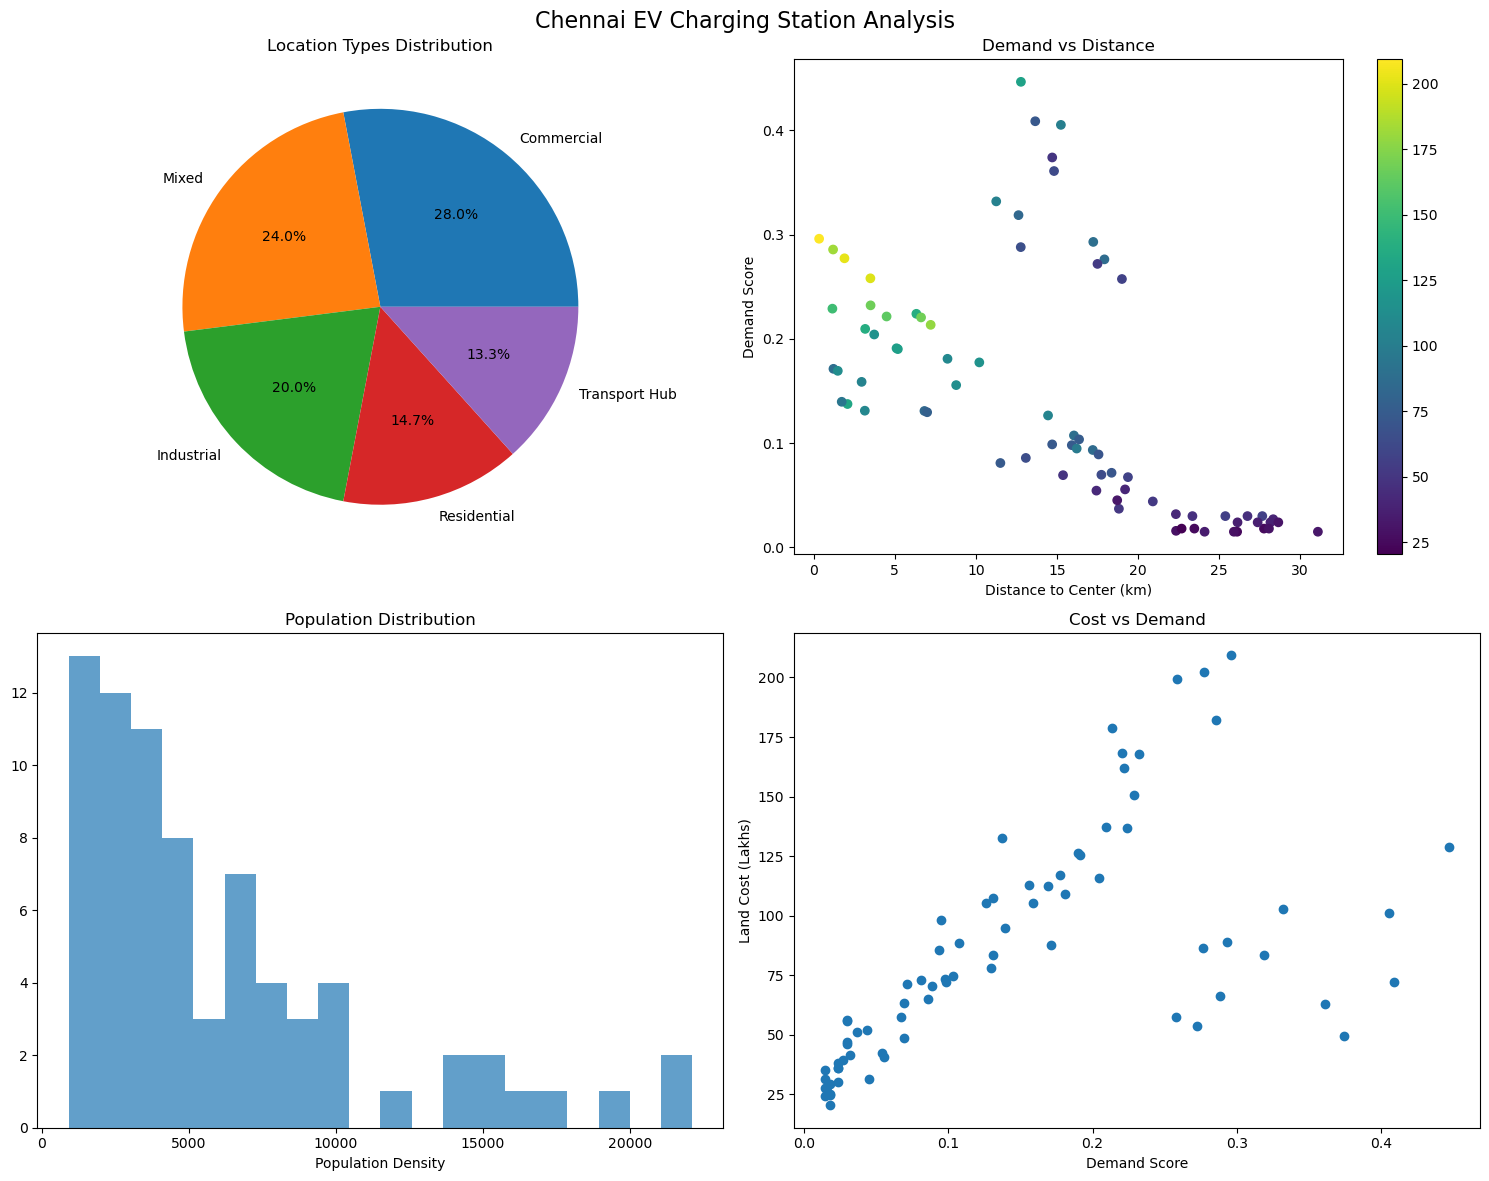

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Chennai EV Charging Station Analysis', fontsize=16)

# Location types distribution
location_counts = featured_data['location_type'].value_counts()
axes[0, 0].pie(location_counts.values, labels=location_counts.index, autopct='%1.1f%%')
axes[0, 0].set_title('Location Types Distribution')

# Demand vs Distance
scatter = axes[0, 1].scatter(featured_data['distance_to_center'], 
                            featured_data['demand_score'],
                            c=featured_data['land_cost_lakhs'], cmap='viridis')
axes[0, 1].set_xlabel('Distance to Center (km)')
axes[0, 1].set_ylabel('Demand Score')
axes[0, 1].set_title('Demand vs Distance')
plt.colorbar(scatter, ax=axes[0, 1])

# Population density
axes[1, 0].hist(featured_data['population_density'], bins=20, alpha=0.7)
axes[1, 0].set_xlabel('Population Density')
axes[1, 0].set_title('Population Distribution')

# Cost vs Demand
axes[1, 1].scatter(featured_data['demand_score'], featured_data['land_cost_lakhs'])
axes[1, 1].set_xlabel('Demand Score')
axes[1, 1].set_ylabel('Land Cost (Lakhs)')
axes[1, 1].set_title('Cost vs Demand')

plt.tight_layout()
plt.show()

In [18]:
print("Summary Statistics:")
featured_data[['demand_score', 'land_cost_lakhs', 'distance_to_center', 'population_density']].describe()

Summary Statistics:


,demand_score,land_cost_lakhs,distance_to_center,population_density
count,75.000000,75.000000,75.000000,75.000000
mean,0.145125,83.909333,14.688703,6032.266667
std,0.115617,47.818415,8.795742,4948.808684
min,0.015000,20.400000,0.325565,912.000000
25%,0.034451,46.350000,6.720882,2655.500000
50%,0.126551,72.900000,15.380000,4280.000000
75%,0.222797,110.600000,21.632534,7685.000000
max,0.446639,209.300000,31.108917,22108.000000


## K-Means Optimization

In [19]:
def optimize_charging_stations_kmeans(df, n_stations=10):
    print(f"Starting K-Means optimization for {n_stations} stations...")
    
    # Prepare features
    feature_columns = ['demand_score', 'population_density', 'latitude', 'longitude']
    df['inverse_cost'] = 1.0 / (df['land_cost_lakhs'] / 100.0 + 0.01)
    feature_columns.append('inverse_cost')
    
    X = df[feature_columns].copy()
    
    return X, feature_columns

In [20]:
X, feature_columns = optimize_charging_stations_kmeans(featured_data, 12)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Starting K-Means optimization for 12 stations...
Feature matrix shape: (75, 5)


In [21]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=12, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans.fit_predict(X_scaled)

featured_data['cluster'] = cluster_labels
print(f"Clustering completed with {len(np.unique(cluster_labels))} clusters")

Clustering completed with 12 clusters


In [22]:
# Select optimal location from each cluster
selected_locations = []

for cluster_id in range(12):
    cluster_data = featured_data[featured_data['cluster'] == cluster_id]
    
    if len(cluster_data) > 0:
        cluster_center = kmeans.cluster_centers_[cluster_id]
        cluster_scaled = scaler.transform(cluster_data[feature_columns])
        distances = np.linalg.norm(cluster_scaled - cluster_center, axis=1)
        
        closest_idx = np.argmin(distances)
        selected_location = cluster_data.iloc[closest_idx]
        selected_locations.append(selected_location)
        
        print(f"Cluster {cluster_id}: Selected {selected_location['location_id']} "
              f"(demand={selected_location['demand_score']:.3f})")

selected_df = pd.DataFrame(selected_locations)

Cluster 0: Selected LOC_004 (demand=0.027)
Cluster 1: Selected LOC_029 (demand=0.140)
Cluster 2: Selected LOC_034 (demand=0.288)
Cluster 3: Selected LOC_023 (demand=0.015)
Cluster 4: Selected LOC_055 (demand=0.067)
Cluster 5: Selected LOC_008 (demand=0.296)
Cluster 6: Selected LOC_064 (demand=0.089)
Cluster 7: Selected LOC_061 (demand=0.018)
Cluster 8: Selected LOC_048 (demand=0.131)
Cluster 9: Selected LOC_073 (demand=0.232)
Cluster 10: Selected LOC_059 (demand=0.361)
Cluster 11: Selected LOC_021 (demand=0.107)


## Performance Metrics

In [23]:
def calculate_metrics(all_locations, selected_locations):
    metrics = {}
    
    # Coverage metrics
    metrics['total_demand_covered'] = selected_locations['demand_score'].sum()
    metrics['avg_demand_score'] = selected_locations['demand_score'].mean()
    metrics['max_possible_demand'] = all_locations['demand_score'].sum()
    metrics['coverage_ratio'] = metrics['total_demand_covered'] / metrics['max_possible_demand']
    
    # Cost metrics
    metrics['total_cost'] = selected_locations['land_cost_lakhs'].sum()
    metrics['avg_cost'] = selected_locations['land_cost_lakhs'].mean()
    metrics['cost_efficiency'] = metrics['total_demand_covered'] / metrics['total_cost']
    
    return metrics

metrics = calculate_metrics(featured_data, selected_df)

In [24]:
# Calculate silhouette score
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
metrics['silhouette_score'] = silhouette_avg

print("Optimization Results:")
print(f"Total Demand Covered: {metrics['total_demand_covered']:.3f} ({metrics['coverage_ratio']*100:.1f}%)")
print(f"Total Cost: Rs {metrics['total_cost']:.1f} Lakhs")
print(f"Cost Efficiency: {metrics['cost_efficiency']:.4f}")
print(f"Silhouette Score: {metrics['silhouette_score']:.3f}")

Optimization Results:
Total Demand Covered: 1.772 (16.3%)
Total Cost: Rs 988.9 Lakhs
Cost Efficiency: 0.0018
Silhouette Score: 0.363


## Results Analysis

In [25]:
# Selected charging stations analysis
print("SELECTED CHARGING STATIONS (Ranked by Demand):")
print("=" * 60)

selected_summary = selected_df[['location_id', 'location_type', 'demand_score', 
                               'land_cost_lakhs', 'distance_to_center', 'population_density']].copy()
selected_summary = selected_summary.sort_values('demand_score', ascending=False).reset_index(drop=True)
selected_summary.index = selected_summary.index + 1  # Start ranking from 1

# Add daily users calculation
selected_summary['daily_users'] = (selected_summary['demand_score'] * 
                                 selected_summary['population_density'] * 25 / 1000).round().astype(int)

# Rename columns for better display
selected_summary.columns = ['Location ID', 'Type', 'Demand Score', 'Cost (₹L)', 
                           'Distance (km)', 'Population/km²', 'Daily Users']

display(selected_summary.round(3))


SELECTED CHARGING STATIONS (Ranked by Demand):


,Location ID,Type,Demand Score,Cost (₹L),Distance (km),Population/km²,Daily Users
1,LOC_059,Residential,0.361,62.9,14.824,7766.0,70
2,LOC_008,Commercial,0.296,209.3,0.326,22108.0,164
3,LOC_034,Industrial,0.288,66.1,12.770,3074.0,22
4,LOC_073,Transport Hub,0.232,167.7,3.501,16442.0,95
5,LOC_029,Residential,0.140,94.9,1.720,8322.0,29
6,LOC_048,Industrial,0.131,83.5,6.825,3256.0,11
7,LOC_021,Commercial,0.107,88.7,16.052,3995.0,11
8,LOC_064,Commercial,0.089,70.5,17.571,1812.0,4
9,LOC_055,Commercial,0.067,57.6,19.386,3247.0,5
10,LOC_004,Transport Hub,0.027,39.5,28.351,2175.0,1


## Interactive Map Visualization

In [27]:
def create_map(selected_locations, all_locations, coverage_radius=2000):
   
    chennai_center = [13.0827, 80.2707]
    m = folium.Map(
        location=chennai_center,
        zoom_start=11,
        tiles='OpenStreetMap'
    )
    

    cluster_colors = [
        'red', 'blue', 'green', 'purple', 'orange', 'darkred',
        'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 'darkpurple'
    ]
    
    
    for idx, row in all_locations.iterrows():
        cluster_color = cluster_colors[row['cluster'] % len(cluster_colors)]
        
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=4,
            color=cluster_color,
            fillColor=cluster_color,
            fillOpacity=0.6,
            weight=1,
            popup=f"""
            <b>{row['location_id']}</b><br>
            Type: {row['location_type']}<br>
            Demand: {row['demand_score']:.3f}<br>
            Cost: ₹{row['land_cost_lakhs']:.1f}L<br>
            Cluster: {row['cluster']}
            """
        ).add_to(m)
    
    
    for idx, row in selected_locations.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=f"""
            <div style="width:200px">
            <h4>🔋 EV Charging Station</h4>
            <b>ID:</b> {row['location_id']}<br>
            <b>Type:</b> {row['location_type']}<br>
            <b>Demand Score:</b> {row['demand_score']:.3f}<br>
            <b>Land Cost:</b> ₹{row['land_cost_lakhs']:.1f} Lakhs<br>
            <b>Population:</b> {row['population_density']:.0f}/km²<br>
            <b>Distance to Center:</b> {row['distance_to_center']:.1f} km
            </div>
            """,
            tooltip=f"⚡ Station {row['location_id']} - Demand: {row['demand_score']:.3f}",
            icon=folium.Icon(color='red', icon='bolt', prefix='fa')
        ).add_to(m)
        
        
        folium.Circle(
            location=[row['latitude'], row['longitude']],
            radius=coverage_radius,  
            color='red',
            fillColor='red',
            fillOpacity=0.1,
            weight=2,
            dash_array='5, 5'
        ).add_to(m)
    
    
    legend_html = """
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 300px; height: 180px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px; border-radius: 10px;
                box-shadow: 0 0 15px rgba(0,0,0,0.2);">
    
    <h4 style="margin-top:0; color: #333;">🗺️ Chennai EV Station Map</h4>
    
    <p style="margin:5px 0;"><span style="color:red;">⚡</span> <b>Selected EV Stations</b> (12 locations)</p>
    
    <p style="margin:5px 0;"><span style="color:red; font-size:20px;">○</span> <b>Coverage Areas</b> (2km radius)</p>
    
    <p style="margin:5px 0;"><span style="color:blue; font-size:12px;">●</span> <b>Candidate Locations</b> (colored by cluster)</p>
    
    <p style="margin:5px 0;">🏢 Commercial &nbsp; 🏠 Residential &nbsp; 🚉 Transport</p>
    
    <p style="margin:5px 0;">🏭 Industrial &nbsp; 🏘️ Mixed Use</p>
    </div>
    """
    
    
    m.get_root().html.add_child(folium.Element(legend_html))
    
    
    plugins.Fullscreen().add_to(m)
    
    return m


In [28]:
output_map = create_map(
    selected_locations=selected_df,
    all_locations=featured_data,
    coverage_radius=2000)
output_map


## Summary Dashboard

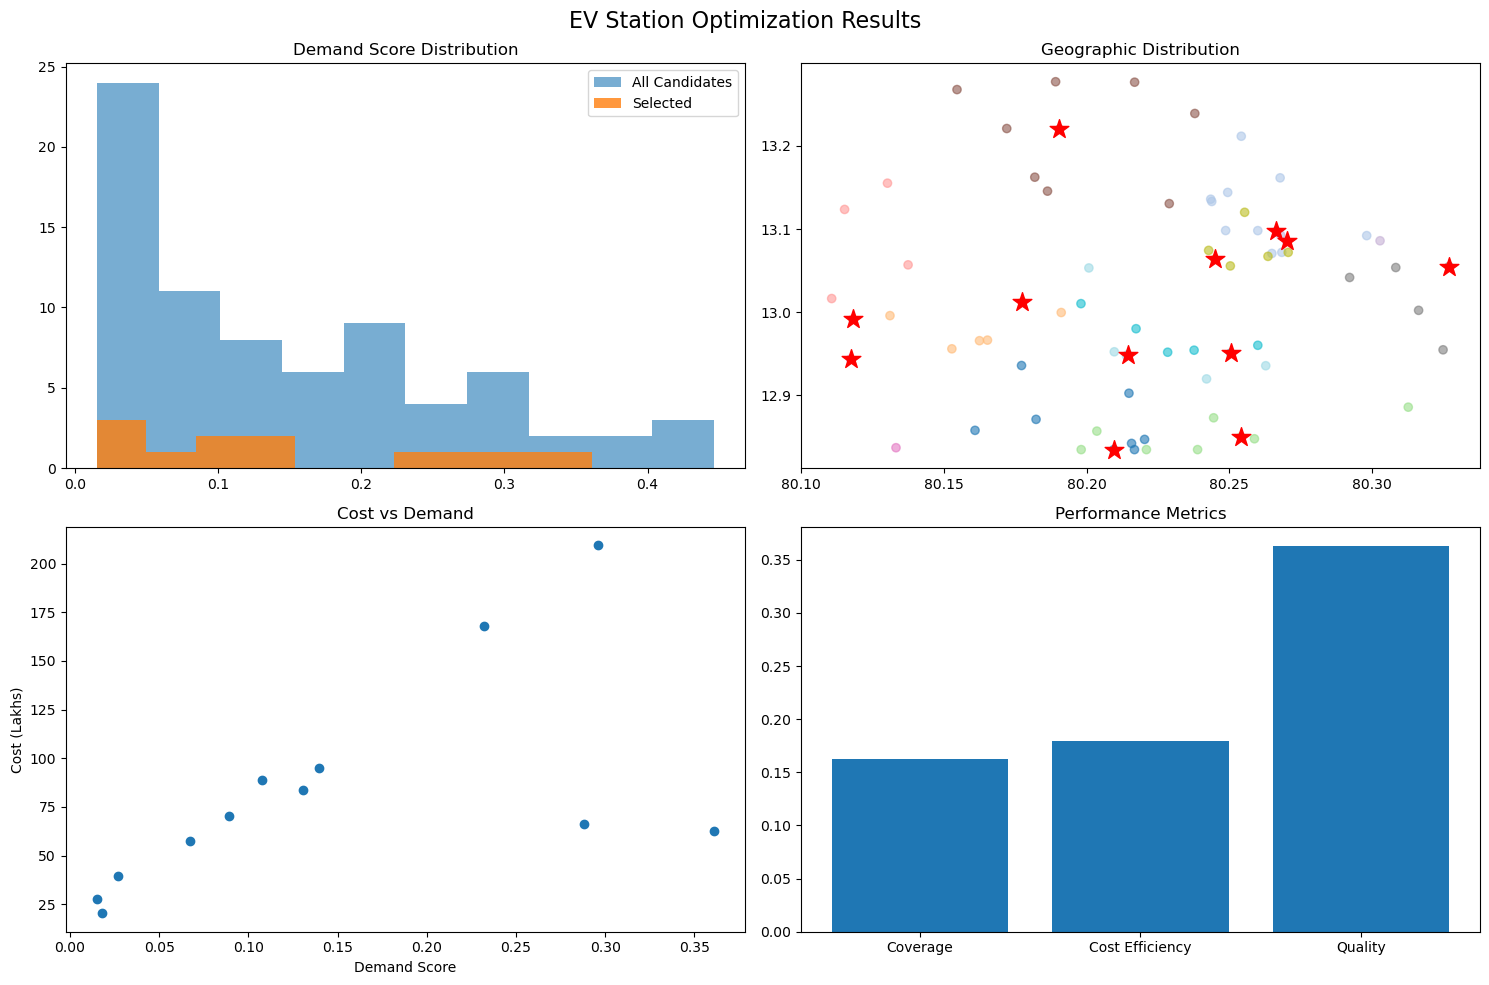

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('EV Station Optimization Results', fontsize=16)

# Demand comparison
axes[0, 0].hist(featured_data['demand_score'], alpha=0.6, label='All Candidates')
axes[0, 0].hist(selected_df['demand_score'], alpha=0.8, label='Selected')
axes[0, 0].set_title('Demand Score Distribution')
axes[0, 0].legend()

# Geographic distribution
axes[0, 1].scatter(featured_data['longitude'], featured_data['latitude'], 
                   c=featured_data['cluster'], cmap='tab20', alpha=0.6)
axes[0, 1].scatter(selected_df['longitude'], selected_df['latitude'], 
                   s=200, c='red', marker='*')
axes[0, 1].set_title('Geographic Distribution')

# Cost analysis
axes[1, 0].scatter(selected_df['demand_score'], selected_df['land_cost_lakhs'])
axes[1, 0].set_xlabel('Demand Score')
axes[1, 0].set_ylabel('Cost (Lakhs)')
axes[1, 0].set_title('Cost vs Demand')

# Performance metrics
metrics_names = ['Coverage', 'Cost Efficiency', 'Quality']
metrics_values = [metrics['coverage_ratio'], 
                 min(1.0, metrics['cost_efficiency']/0.01), 
                 metrics['silhouette_score']]
axes[1, 1].bar(metrics_names, metrics_values)
axes[1, 1].set_title('Performance Metrics')

plt.tight_layout()
plt.show()

In [30]:
print("PROJECT SUMMARY:")
print(f"Total Stations Optimized: {len(selected_df)}")
print(f"Demand Coverage: {metrics['coverage_ratio']*100:.1f}%")
print(f"Total Investment: Rs {metrics['total_cost']:.1f} Lakhs")
print(f"Average Demand Score: {metrics['avg_demand_score']:.3f}")
print(f"Clustering Quality: {metrics['silhouette_score']:.3f}")
print("\nOptimization completed successfully!")

PROJECT SUMMARY:
Total Stations Optimized: 12
Demand Coverage: 16.3%
Total Investment: Rs 988.9 Lakhs
Average Demand Score: 0.148
Clustering Quality: 0.363

Optimization completed successfully!
